# Local Model Playground

Interactive notebook to pick a local VLM and run a single 2AFC trial (using generated answers or logit-based confidence measures) on GPU.

In [6]:
# Cell 1 — Setup & imports
import os
import sys
import gc
from pathlib import Path
import base64
from io import BytesIO

import torch

# Ensure the repo root is on sys.path so we can import evaluation_pipe
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dotenv import load_dotenv
load_dotenv()  # loads HF_TOKEN, IMAGE_DATASET, etc.

from PIL import Image
from IPython.display import display, HTML

from evaluation_pipe.models import create_model, list_models
from evaluation_pipe.models.base import ModelResponse
from evaluation_pipe.data import load_trials

IMAGE_DATASET = REPO_ROOT / os.environ["IMAGE_DATASET"]
print(f"Imports OK — IMAGE_DATASET={IMAGE_DATASET}")

THUMB_SIZE = 200

def _img_to_b64(img: Image.Image, size: int = THUMB_SIZE) -> str:
    thumb = img.copy()
    thumb.thumbnail((size, size))
    buf = BytesIO()
    thumb.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

def show_trial(ref, img_a, img_b, a_label="A", b_label="B"):
    cells = ""
    for img, label in [(ref, "Reference"), (img_a, a_label), (img_b, b_label)]:
        b64 = _img_to_b64(img)
        cells += f'<td style="text-align:center"><b>{label}</b><br><img src="data:image/png;base64,{b64}"></td>'
    display(HTML(f"<table><tr>{cells}</tr></table>"))

Imports OK — IMAGE_DATASET=/Users/Jorda/Documents/GitHub/shapebias-bench2-logit/stimuli_pipe/stimuli_per_stl_packages/stimuli_A_auto_contrast


In [7]:
#Cell 2 - Experiment Setup
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("Using device:", DEVICE)

#Currently set for no-word condition.
PROMPT = (
    "You are given three images. The first image is the reference. "
    "Which of the other two images (A or B) is more similar to the reference? "
    "Answer with just 'A' or 'B'."
)
print("Available models:", list_models())

# Load trial 1 for testing all models
trials = load_trials(IMAGE_DATASET, order="shape_first")
trial_idx = 0
trial = trials[trial_idx]
print(f"Using trial {trial.trial_id} (ground_truth={trial.ground_truth})")

Using device: mps
Available models: ['internvl', 'internvl-2b', 'qwen3-vl-2b', 'qwen3-vl-3b', 'qwen3-vl-4b', 'qwen3.5-0.8b', 'qwen3.5-1.7b', 'qwen3.5-4b', 'smolvlm', 'smolvlm-256m']
Using trial 1 (ground_truth=A)


In [ ]:
# Load next trial
trial_idx = (trial_idx + 1) % len(trials)
trial = trials[trial_idx]

Reference,A (shape_match),B (texture_match)

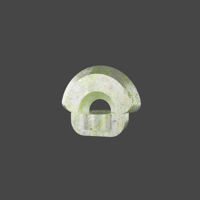
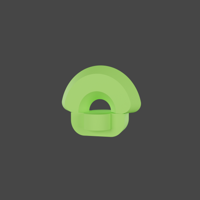
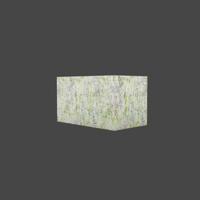

In [8]:
# Display current trial
reference, image_a, image_b = trial.load_images()
display(HTML("<b>Reference | Image A (shape_match) | Image B (texture_match)</b>"))
show_trial(reference, image_a, image_b, "A (shape_match)", "B (texture_match)")

## SmolVLM

In [9]:
# Load model (do not need to rerun between trials)

model = create_model("smolvlm", device=DEVICE)
print(DEVICE)
print(next(model._model.parameters()).device)
print(f"Loaded: {model.name}")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

mps
mps:0
Loaded: HuggingFaceTB/SmolVLM2-2.2B-Instruct


In [ ]:
# Run generated answer trial (can be rerun)
response = model.generate(images=[reference, image_a, image_b], prompt=PROMPT)
print(f"Answer: {response.raw_text}")
print(f"Time:   {response.generation_time_s:.2f}s")
print(f"Tokens: {response.num_tokens_generated}")

In [10]:
# Run logit evaluation trial (can be rerun)

#Testing on the AB prompt
response = model.score_choices(images=[reference, image_a, image_b], prompt=PROMPT, choice_texts = ('A', 'B'))
print(f"Choices:      {response['choice_texts']}")
print(f"Logits:       {response['choice_logits']}")
print(f"Absolute Probabilities: {response['choice_probs_absolute']}")
print(f"Relative Probabilities: {response['choice_probs_relative']}")
print(f"Time:         {response['generation_time_s']:.2f}s")
print(f"Tokens:   {response['num_tokens_generated']}")

NameError: name 'sel' is not defined

In [5]:
# Unload model (run if switching between models)
model.unload()
del model, reference, image_a, image_b
gc.collect()
torch.cuda.empty_cache()
print("SmolVLM unloaded — GPU memory freed.")

SmolVLM unloaded — GPU memory freed.


## InternVL

In [ ]:
# Load model (do not need to rerun between trials)

model = create_model("internvl", device=DEVICE)
print(f"Loaded: {model.name}")

In [ ]:
# Run generated answer trial (can be rerun)x

response = model.generate(images=[reference, image_a, image_b], prompt=PROMPT)
print(f"Answer: {response.raw_text}")
print(f"Time:   {response.generation_time_s:.2f}s")
print(f"Tokens: {response.num_tokens_generated}")

In [ ]:
# Run logit evaluation trial (can be rerun)

#Testing on the AB prompt
response = model.score_choices(images=[reference, image_a, image_b], prompt=PROMPT, choice_texts = ('A', 'B'))
print(f"Choices:      {response['choice_texts']}")
print(f"Logits:       {response['choice_logits']}")
print(f"Absolute Probabilities: {response['choice_probs_absolute']}")
print(f"Relative Probabilities: {response['choice_probs_relative']}")
print(f"Time:         {response['generation_time_s']:.2f}s")
print(f"Tokens:   {response['num_tokens_generated']}")

In [ ]:
# Unload model (run if switching between models)

model.unload()
del model, reference, image_a, image_b
gc.collect()
torch.cuda.empty_cache()
print("InternVL unloaded — GPU memory freed.")

## Qwen3-VL-2B

In [ ]:
# Load model (do not need to rerun between trials)

model = create_model("qwen3-vl-2b", device=DEVICE)
print(f"Loaded: {model.name}")

In [ ]:
# Run generated answer trial (can be rerun)
response = model.generate(images=[reference, image_a, image_b], prompt=PROMPT)
print(f"Answer: {response.raw_text}")
print(f"Time:   {response.generation_time_s:.2f}s")
print(f"Tokens: {response.num_tokens_generated}")

In [ ]:
# Run logit evaluation trial (can be rerun)

#Testing on the AB prompt
response = model.score_choices(images=[reference, image_a, image_b], prompt=PROMPT, choice_texts = ('A', 'B'))
print(f"Choices:      {response['choice_texts']}")
print(f"Logits:       {response['choice_logits']}")
print(f"Absolute Probabilities: {response['choice_probs_absolute']}")
print(f"Relative Probabilities: {response['choice_probs_relative']}")
print(f"Time:         {response['generation_time_s']:.2f}s")
print(f"Tokens:   {response['num_tokens_generated']}")

In [ ]:
# Unload model (run if switching between models)

model.unload()
del model, reference, image_a, image_b
gc.collect()
torch.cuda.empty_cache()
print("Qwen3-VL-2B unloaded — GPU memory freed.")

## Qwen3-VL-4B

In [ ]:
# Load model (do not need to rerun between trials)

model = create_model("qwen3-vl-4b", device=DEVICE)
print(f"Loaded: {model.name}")

In [ ]:
# Run generated answer trial (can be rerun)
response = model.generate(images=[reference, image_a, image_b], prompt=PROMPT)
print(f"Answer: {response.raw_text}")
print(f"Time:   {response.generation_time_s:.2f}s")
print(f"Tokens: {response.num_tokens_generated}")

In [ ]:
# Run logit evaluation trial (can be rerun)

#Testing on the AB prompt
response = model.score_choices(images=[reference, image_a, image_b], prompt=PROMPT, choice_texts = ('A', 'B'))
print(f"Choices:      {response['choice_texts']}")
print(f"Logits:       {response['choice_logits']}")
print(f"Absolute Probabilities: {response['choice_probs_absolute']}")
print(f"Relative Probabilities: {response['choice_probs_relative']}")
print(f"Time:         {response['generation_time_s']:.2f}s")
print(f"Tokens:   {response['num_tokens_generated']}")

In [ ]:
# Unload model (run if switching between models)

model.unload()
del model, reference, image_a, image_b
gc.collect()
torch.cuda.empty_cache()
print("Qwen3-VL-4B unloaded — GPU memory freed.")

## Qwen3.5-0.8B

In [ ]:
# Load model (do not need to rerun between trials)

model = create_model("qwen3.5-0.8b", device=DEVICE)
print(f"Loaded: {model.name}")

In [ ]:
# Run generated answer trial (can be rerun)
response = model.generate(images=[reference, image_a, image_b], prompt=PROMPT)
print(f"Answer: {response.raw_text}")
print(f"Time:   {response.generation_time_s:.2f}s")
print(f"Tokens: {response.num_tokens_generated}")

In [ ]:
# Run logit evaluation trial (can be rerun)

#Testing on the AB prompt
response = model.score_choices(images=[reference, image_a, image_b], prompt=PROMPT, choice_texts = ('A', 'B'))
print(f"Choices:      {response['choice_texts']}")
print(f"Logits:       {response['choice_logits']}")
print(f"Absolute Probabilities: {response['choice_probs_absolute']}")
print(f"Relative Probabilities: {response['choice_probs_relative']}")
print(f"Time:         {response['generation_time_s']:.2f}s")
print(f"Tokens:   {response['num_tokens_generated']}")

In [ ]:
# Unload model (run if switching between models)

model.unload()
del model, reference, image_a, image_b
gc.collect()
torch.cuda.empty_cache()
print("Qwen3.5-0.8B unloaded — GPU memory freed.")

## Qwen3.5-4B

In [ ]:
# Load model (do not need to rerun between trials)

model = create_model("qwen3.5-4b", device=DEVICE)
print(f"Loaded: {model.name}")

In [ ]:
# Run generated answer trial (can be rerun)
response = model.generate(images=[reference, image_a, image_b], prompt=PROMPT)
print(f"Answer: {response.raw_text}")
print(f"Time:   {response.generation_time_s:.2f}s")
print(f"Tokens: {response.num_tokens_generated}")

In [ ]:
# Run logit evaluation trial (can be rerun)

#Testing on the AB prompt
response = model.score_choices(images=[reference, image_a, image_b], prompt=PROMPT, choice_texts = ('A', 'B'))
print(f"Choices:      {response['choice_texts']}")
print(f"Logits:       {response['choice_logits']}")
print(f"Absolute Probabilities: {response['choice_probs_absolute']}")
print(f"Relative Probabilities: {response['choice_probs_relative']}")
print(f"Time:         {response['generation_time_s']:.2f}s")
print(f"Tokens:   {response['num_tokens_generated']}")

In [ ]:
# Unload model (run if switching between models)

model.unload()
del model, reference, image_a, image_b
gc.collect()
torch.cuda.empty_cache()
print("Qwen3.5-4B unloaded — GPU memory freed.")